In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras
import torch
torch.cuda.is_available()
from keras.models import Sequential, Model
from keras.layers import (Dense, Input, Flatten, Reshape, Rescaling, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Concatenate, AveragePooling2D, ReLU
                          Dropout, RandomFlip, RandomRotation, RandomCrop, RandomShear, RandomZoom, RandomContrast, RandomTranslation, RandomErasing)
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam, RMSprop
from keras.metrics import Accuracy
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from keras.utils import plot_model


In [2]:
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train,y_train, train_size= 0.8, random_state=1)


In [3]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(40000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 32, 32, 3)


In [4]:
class_names= [
"airplane",
"automobile",
"bird",
"cat",
"deer",
"dog",
"frog",
"horse",
"ship",
"truck"
]

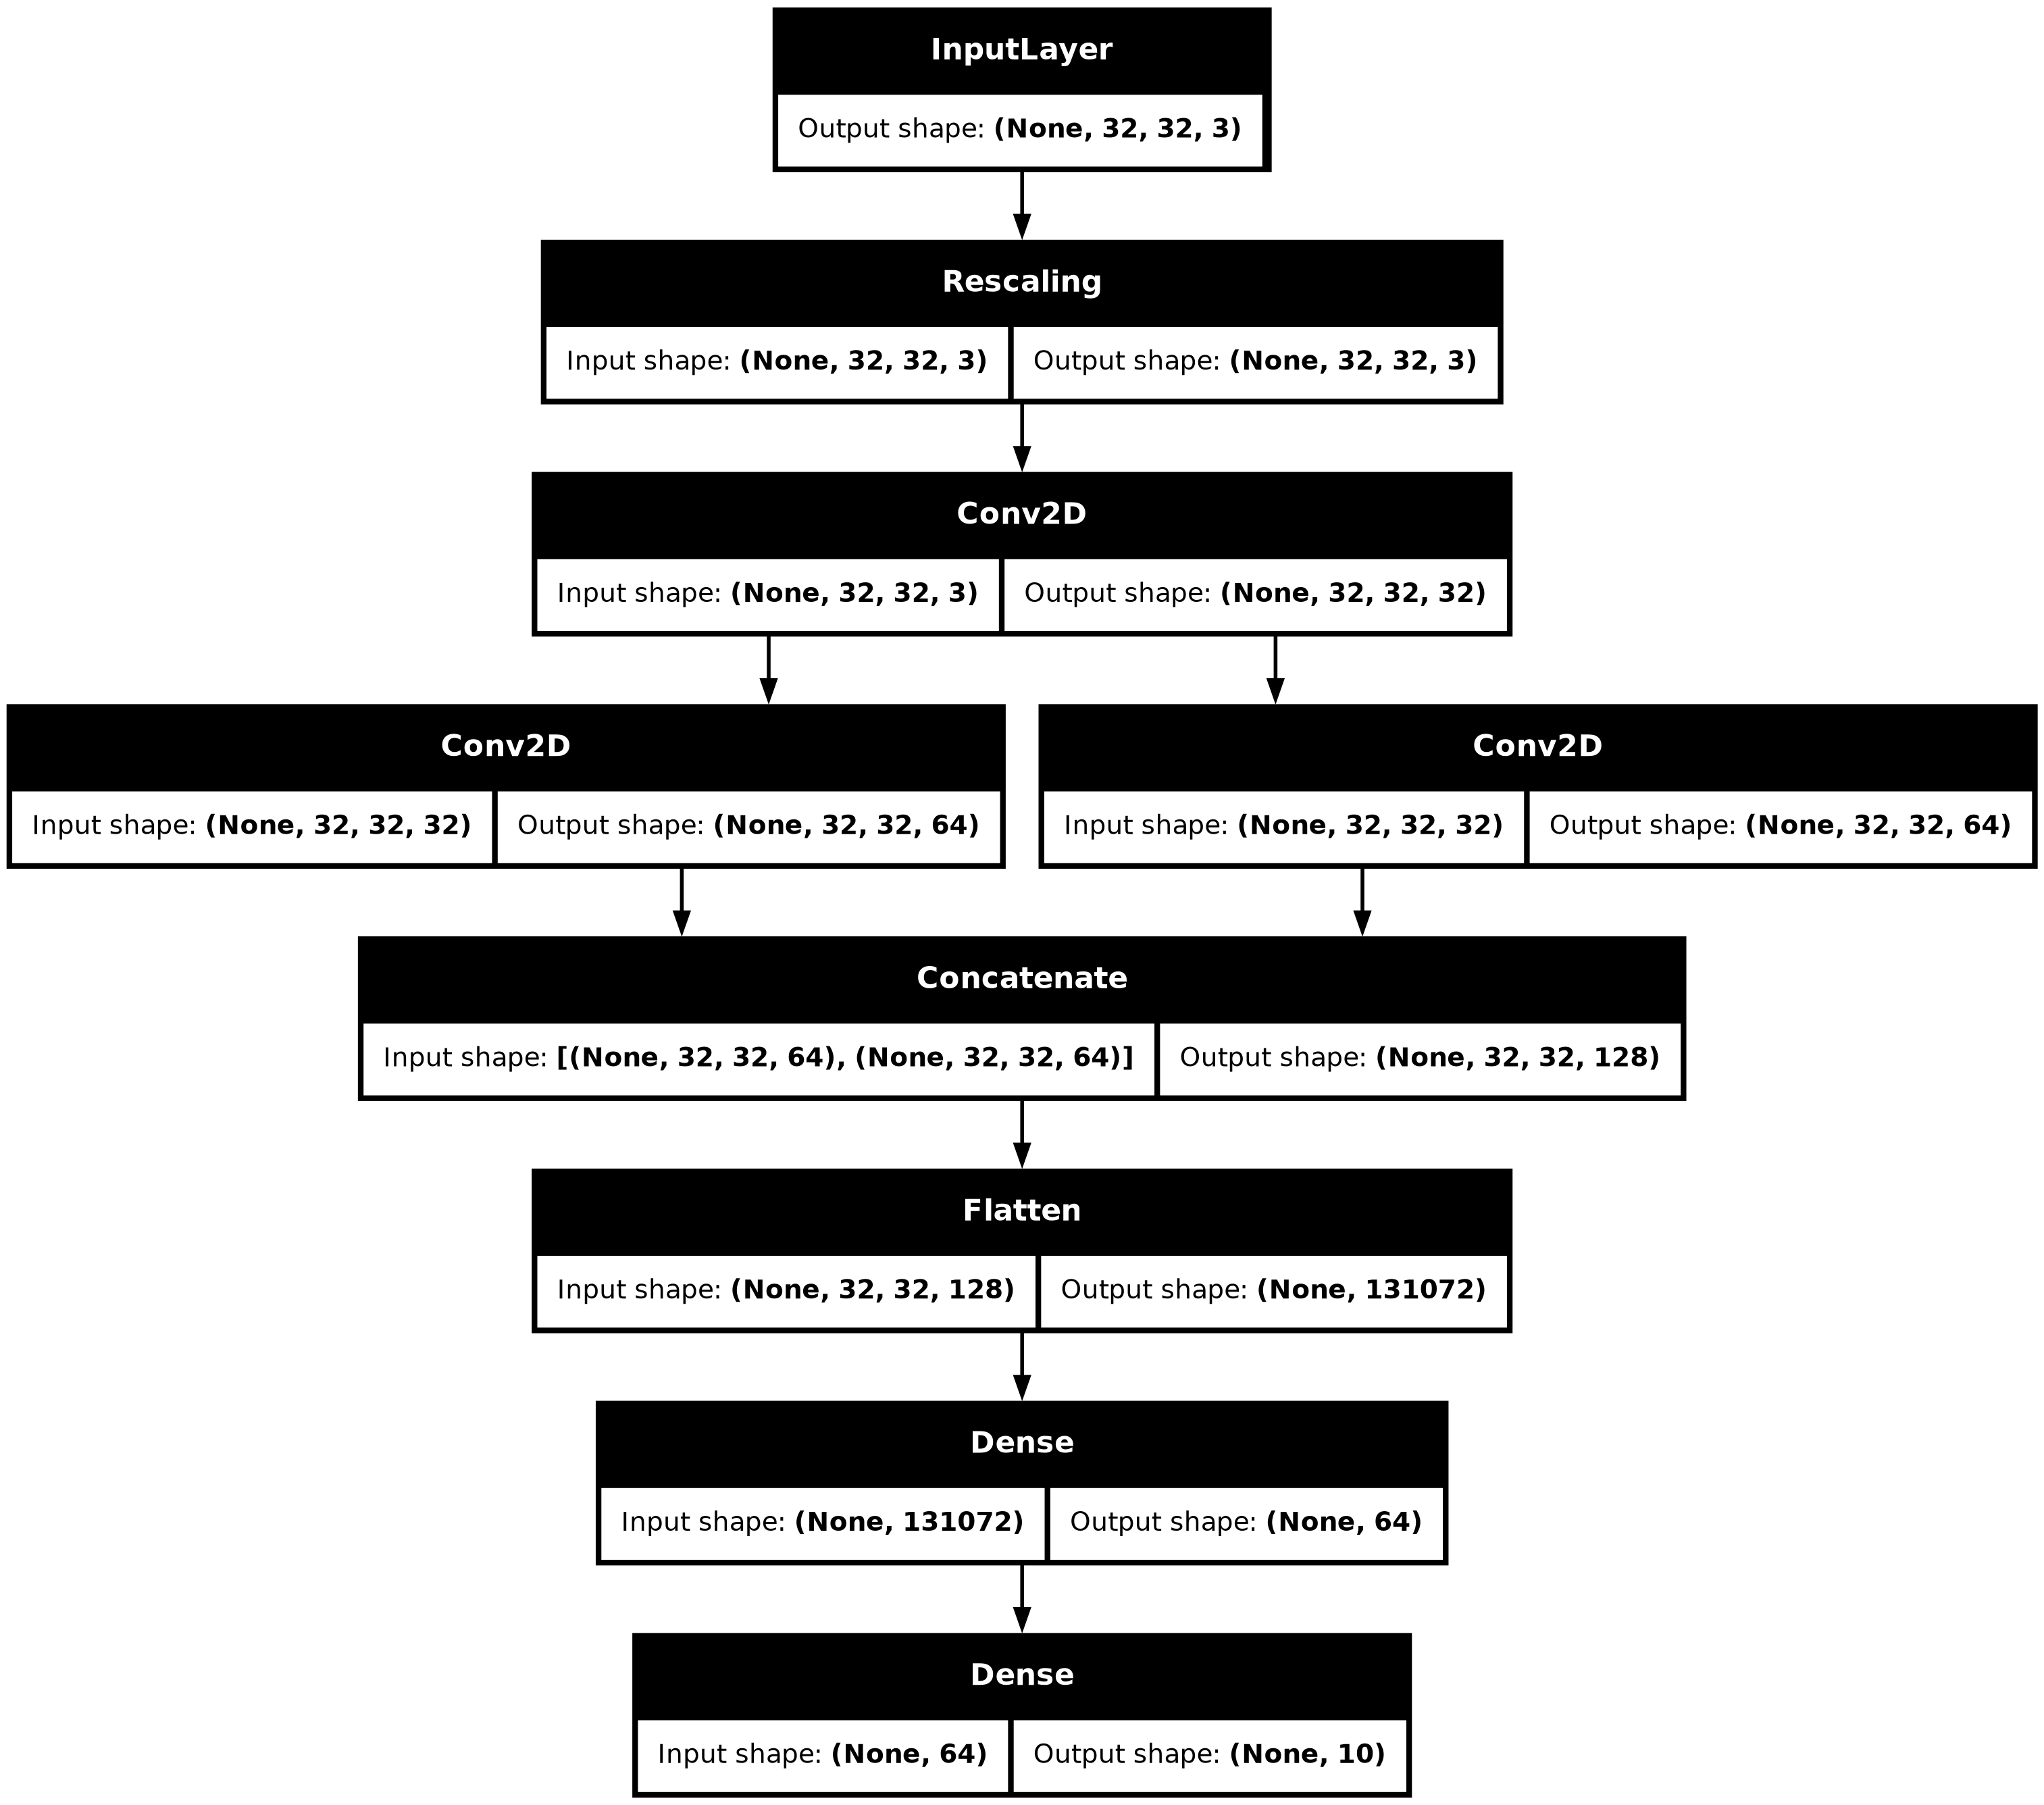

In [ ]:
def block1(inputs, filers: int = 64):
  x = Conv2D(64,3,1,'same')(inputs)
  x = ReLU()(x)
  x = Conv2D(64,3,1,'same')(x)
  x = ReLU()(x)
  x = MaxPooling2D(2)(x)

def block2(inputs, filters: int=64):
  x = AveragePooling2D()()
  


inputs = Input(x_train.shape[1:])
x = Rescaling(1./255)(inputs)
x = Conv2D(32,2,activation='relu', padding='same')(x)

left = Conv2D(64,5,activation='relu', padding='same')(x)
right = Conv2D(64,1,activation='relu', padding='same')(x)

x = Concatenate()([left, right])
x = Flatten()(x)
x = Dense(64,activation='relu')(x)

out = Dense(10, activation='softmax')(x)

cnn = Model(inputs = inputs, outputs= out)
plot_model(cnn, expand_nested=True, show_shapes=True)